# **Proyecto ML - Parte 1:**
Jose Manuel Fonseca -202122456\
Julian Pinto - \
Daniel Vergara - 

## Contexto y objetivo

En este proyecto vamos a clasificar reseñas de productos en español como positivas, negativas o neutrales. Algunas reseñas mezclan cosas buenas y malas del producto, por lo que no siempre es fácil identificar la opinión general.

Tenemos 12.000 reseñas con etiqueta para entrenar y evaluar el modelo, y 3.000 sin etiqueta para generar las predicciones que enviaremos a Kaggle.

Para esta primera parte usaremos TF-IDF y modelos clásicos de scikit-learn. Empezaremos con un modelo sencillo y probaremos si tener en cuenta la parte final de las reseñas ayuda a mejorar los resultados.

La métrica principal será accuracy, que mide la proporción de reseñas clasificadas correctamente. También revisaremos los errores para entender en qué casos falla el modelo.

# Imports

In [7]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
RANDOM_STATE = 42


# Cargar datos

In [9]:
train = pd.read_csv("train.csv")
eval_df = pd.read_csv("eval.csv")

print("train:", train.shape)
print("eval:", eval_df.shape)
train.head()

train: (12000, 3)
eval: (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


Valores nulos por columna


,train,eval
id,0,0.0
label,0,No aplica
text,0,0.0


Textos duplicados


,train,eval
Duplicados,0,0


Distribución de clases


,Cantidad,Porcentaje
Etiqueta,,
positivo,4212,35.1
negativo,4212,35.1
neutral,3576,29.8


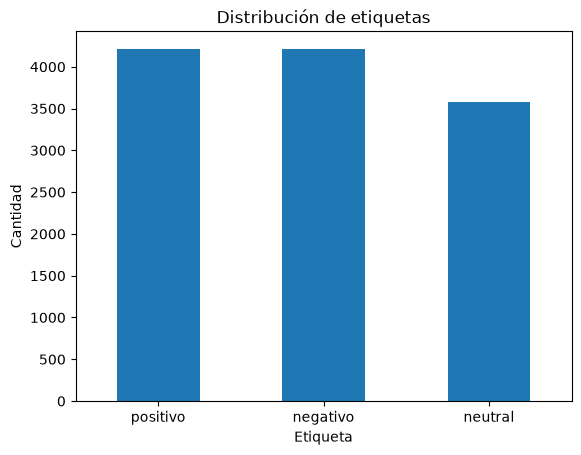

In [17]:
print("Valores nulos por columna")
display(pd.DataFrame({
    "train": train.isna().sum(),
    "eval": eval_df.isna().sum(),
}).fillna("No aplica"))

print("Textos duplicados")
display(pd.DataFrame({
    "train": [train["text"].duplicated().sum()],
    "eval": [eval_df["text"].duplicated().sum()],
}, index=["Duplicados"]))

conteos = train["label"].value_counts()

print("Distribución de clases")
display(pd.DataFrame({
    "Cantidad": conteos,
    "Porcentaje": (conteos / len(train) * 100).round(2),
}).rename_axis("Etiqueta"))

conteos.plot(
    kind="bar",
    title="Distribución de etiquetas",
    ylabel="Cantidad",
    xlabel="Etiqueta",
    rot=0,
)
plt.show()

In [18]:
revision = pd.DataFrame({
    "train": [
        train["text"].str.strip().eq("").sum(),
        train["id"].isna().sum(),
        train["id"].duplicated().sum(),
    ],
    "eval": [
        eval_df["text"].str.strip().eq("").sum(),
        eval_df["id"].isna().sum(),
        eval_df["id"].duplicated().sum(),
    ],
}, index=[
    "Textos vacíos o con solo espacios",
    "Identificadores nulos",
    "Identificadores repetidos",
])

display(revision)

,train,eval
Textos vacíos o con solo espacios,0,0
Identificadores nulos,0,0
Identificadores repetidos,0,0


No encontramos textos vacíos ni identificadores nulos o repetidos en
train y eval. Junto con la revisión anterior de valores faltantes y
textos duplicados, no encontramos motivos para eliminar filas.

In [19]:
for etiqueta in ["positivo", "negativo", "neutral"]:
    print(f"\n--- {etiqueta.upper()} ---")

    ejemplos = train.loc[
        train["label"] == etiqueta, "text"
    ].sample(3, random_state=RANDOM_STATE)

    for numero, texto in enumerate(ejemplos, start=1):
        print(f"\n{numero}. {texto}")


--- POSITIVO ---

1. Me llegó el equipo a casa en tres días, lo pedí un martes por la noche y ya estaba probándolo el viernes. Después de usarlo bastante, lo pruebo casi todos los días, más que nada en las tardes después del trabajo. Para mí, el rendimiento me resultó ser mal terminado en el uso real. Lo tengo conectado en el escritorio del cuarto, con el cargador original de 65W. Sin embargo, el procesador se mantuvo espectacular en el uso real.

2. La compré hace un par de meses por internet y llegó en tres días a mi casa. Ya con un tiempo de uso, lo uso para el gimnasio, principalmente cuando voy en las tardes después del trabajo. La instalación la hizo mi cuñado un sábado en la mañana y no hubo ningún problema. Terminé feliz con la instalación.

3. Hace un par de semanas lo pedi porque lo necesitaba para el trabajo, me llego en unos tres dias a la oficina. Me alegra haber elegido la ergonomia. Lo uso todos los dias en el escritorio junto a la laptop. De paso, la app del fabricante

### Observaciones de las reseñas

En los ejemplos positivos y negativos encontramos reseñas que mezclan
elogios y críticas. Por eso, identificar palabras positivas o negativas
por separado puede no ser suficiente para clasificar la opinión general.

En algunos casos, la opinión final coincide con la etiqueta, pero también
hay ejemplos donde ocurre lo contrario. Probaremos si representar la
parte final junto con el texto completo ayuda al modelo.

Los ejemplos neutrales describen principalmente el envío, el uso y las
características del producto. También observamos textos sin tildes y
algunos errores de escritura.

In [21]:
longitudes = train.assign(
    palabras=train["text"].str.split().str.len()
)

display(
    longitudes.groupby("label")["palabras"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

,count,mean,median,min,max
label,,,,,
negativo,4212,54.23,54.0,6,100
neutral,3576,52.28,52.0,3,96
positivo,4212,55.00,55.0,5,110


Las reseñas de las tres clases tienen una longitud similar: el promedio
está entre 52 y 55 palabras y las medianas son cercanas. No observamos
una diferencia marcada de longitud entre las etiquetas.